In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('drug200.csv')

data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [3]:
data.shape

(200, 6)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [5]:
data.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [6]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


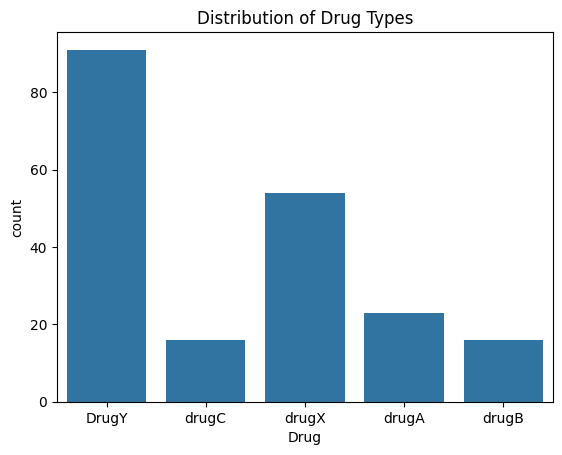

In [7]:
sns.countplot(x='Drug', data=data)
plt.title("Distribution of Drug Types")
plt.show()

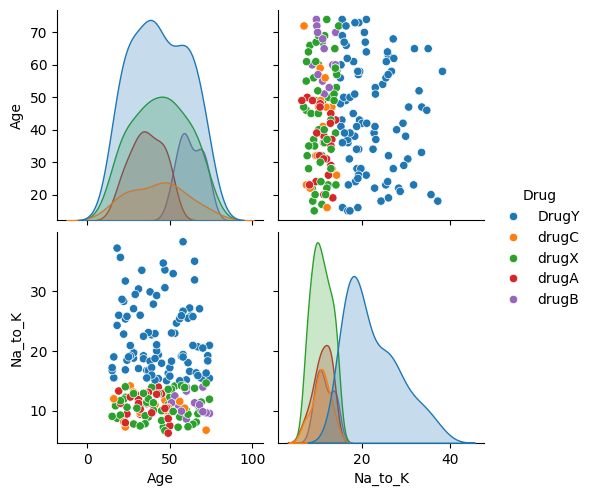

In [8]:
sns.pairplot(data, hue='Drug')
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
temp_data = data.copy()
le = LabelEncoder()

for col in temp_data.columns:
    temp_data[col] = le.fit_transform(temp_data[col])

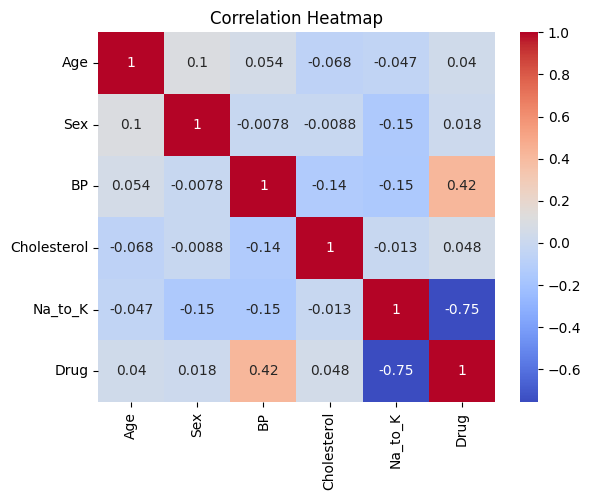

In [11]:
sns.heatmap(temp_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [34]:
le = LabelEncoder()

le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_chol = LabelEncoder()
le_drug = LabelEncoder()

data['Sex'] = le_sex.fit_transform(data['Sex'])
data['BP'] = le_bp.fit_transform(data['BP'])
data['Cholesterol'] = le_chol.fit_transform(data['Cholesterol'])
data['Drug'] = le_drug.fit_transform(data['Drug'])

In [13]:
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


In [14]:
data.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = data.drop('Drug', axis=1)
y = data['Drug']

In [17]:
X

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043
...,...,...,...,...,...
195,56,0,1,0,11.567
196,16,1,1,0,12.006
197,52,1,2,0,9.894
198,23,1,2,1,14.020


In [18]:
y

0      0
1      3
2      3
3      4
4      0
      ..
195    3
196    3
197    4
198    4
199    4
Name: Drug, Length: 200, dtype: int64

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(160, 5) (40, 5)
(160,) (40,)


In [21]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

In [22]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [23]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
rf.score(X_train, y_train)

1.0

In [25]:
y_pred = rf.predict(X_test)
y_pred

array([4, 0, 4, 3, 0, 0, 0, 4, 1, 4, 1, 4, 0, 1, 2, 0, 2, 4, 3, 0, 2, 4,
       4, 0, 0, 0, 3, 4, 0, 4, 0, 3, 3, 0, 1, 0, 4, 1, 0, 1])

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
def model_evaluation(y_actual, y_prediction):
    print('Accuracy_Score = ',accuracy_score(y_actual, y_prediction))
    print('Confusion Matrix \n',confusion_matrix(y_actual, y_prediction))
    sns.heatmap(confusion_matrix(y_actual, y_prediction), annot = True, fmt = '.2f')
    print('Classification_Report \n',classification_report(y_actual, y_prediction))

Accuracy_Score =  1.0
Confusion Matrix 
 [[15  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  5  0]
 [ 0  0  0  0 11]]
Classification_Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



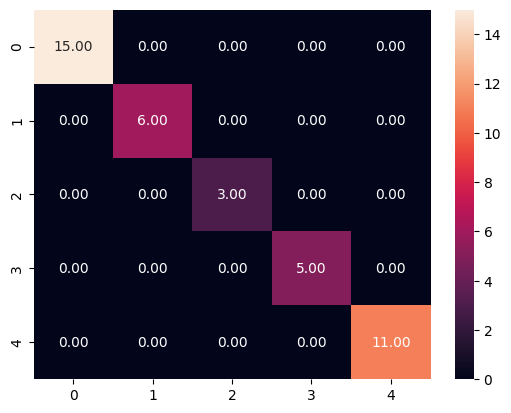

In [27]:
model_evaluation(y_test, y_pred)

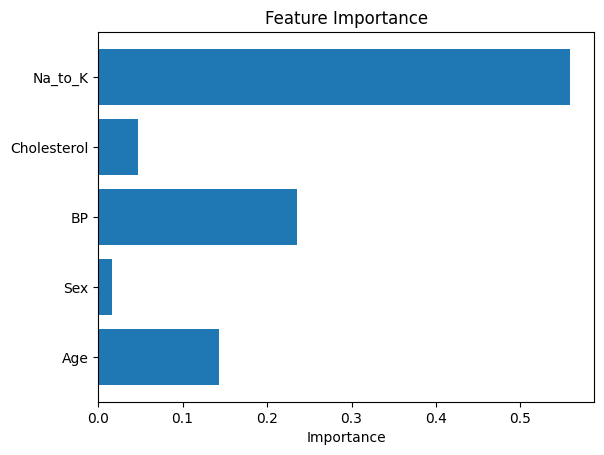

In [28]:
importances = rf.feature_importances_
features = X.columns

# Plot
plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [29]:
sample = [[45, 1, 2, 1, 25]]  
# Format: Age, Sex, BP, Cholesterol, Na_to_K

prediction = rf.predict(sample)

print("Predicted Drug Class:", prediction)

Predicted Drug Class: [0]


C:\Users\Sujal Damor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [30]:
sample_df = pd.DataFrame(
    [[45, 1, 2, 1, 25]],
    columns=['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
)

prediction = rf.predict(sample_df)
predicted_drug = le.inverse_transform(prediction)

print("Predicted Drug:", predicted_drug)

Predicted Drug: ['DrugY']


In [32]:
import pickle

# Save model
pickle.dump(rf, open("model.pkl", "wb"))



In [35]:
pickle.dump((le_sex, le_bp, le_chol, le_drug), open("encoders.pkl", "wb"))

In [36]:
import os
print("Current Directory:", os.getcwd())
print("Files in folder:", os.listdir())

Current Directory: C:\Users\Sujal Damor\OneDrive\Desktop\My career\8 sem project
Files in folder: ['.ipynb_checkpoints', 'app.py', 'Drug Ai app', 'drug recommendation.ipynb', 'drug200.csv', 'encoders.pkl', 'model.pkl']
